In [1]:
!pip install pandas numpy matplotlib pandas_datareader yfinance


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

plt.style.use('fivethirtyeight')
%matplotlib inline

In [3]:
import yfinance as yf
import datetime as dt

stock = "POWERGRID.NS"
start = dt.datetime(2000, 1, 1)
end = dt.datetime(2026, 10, 7)

df = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,
2007-10-05,30.896240,33.629606,25.537001,27.579348,855215656
2007-10-08,29.314571,31.940444,29.130299,31.940444,126671715
2007-10-09,31.310837,31.587243,27.748250,29.329915,116725709
2007-10-10,31.602623,32.247575,31.326216,32.124726,67931378
2007-10-11,35.134483,36.854354,31.326202,36.854354,106320954


In [5]:
df.shape

(4628, 5)

In [6]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4628 entries, 2007-10-05 to 2026-07-10
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, POWERGRID.NS)   4628 non-null   float64
 1   (High, POWERGRID.NS)    4628 non-null   float64
 2   (Low, POWERGRID.NS)     4628 non-null   float64
 3   (Open, POWERGRID.NS)    4628 non-null   float64
 4   (Volume, POWERGRID.NS)  4628 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 216.9 KB


In [7]:
df.isnull().sum()

Price   Ticker      
Close   POWERGRID.NS    0
High    POWERGRID.NS    0
Low     POWERGRID.NS    0
Open    POWERGRID.NS    0
Volume  POWERGRID.NS    0
dtype: int64

In [8]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
count,4628.000000,4628.000000,4628.000000,4628.000000,4.628000e+03
mean,95.021388,96.200339,93.858177,95.070947,1.197638e+07
std,84.192040,85.106558,83.254482,84.215328,1.978644e+07
min,18.038855,19.282913,16.172767,19.189608,0.000000e+00
25%,35.371078,35.932289,34.891153,35.413977,5.044258e+06
50%,66.134987,67.082329,65.295955,66.292304,8.693871e+06
75%,114.210049,115.906080,112.735225,114.460753,1.389424e+07
max,344.843262,345.598106,337.058457,343.522181,8.552157e+08


In [9]:
df = df.reset_index()

In [10]:
df.columns

MultiIndex([(  'Date',             ''),
            ( 'Close', 'POWERGRID.NS'),
            (  'High', 'POWERGRID.NS'),
            (   'Low', 'POWERGRID.NS'),
            (  'Open', 'POWERGRID.NS'),
            ('Volume', 'POWERGRID.NS')],
           names=['Price', 'Ticker'])

In [11]:
df.to_csv("powergrid.csv")

In [12]:
data01 = pd.read_csv("powergrid.csv")

In [13]:
data01.head()

,Price,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,2007-10-05,30.896240234375,33.62960604727621,25.53700130653391,27.579347988281896,855215656
2,1,2007-10-08,29.314571380615234,31.940444166313526,29.130298802297208,31.940444166313526,126671715
3,2,2007-10-09,31.310836791992188,31.587243472262923,27.748250230796387,29.329914613165748,116725709
4,3,2007-10-10,31.602622985839844,32.247575155441034,31.32621610331857,32.124726032151514,67931378


In [14]:
!pip install plotly


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# Candlesticks 
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x = data01['Date'], open = data01['Open'], 
                                    high = data01['High'],
                                    low = data01['Low'], 
                                    close = data01['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

In [17]:
print(df.columns)

MultiIndex([(  'Date',             ''),
            ( 'Close', 'POWERGRID.NS'),
            (  'High', 'POWERGRID.NS'),
            (   'Low', 'POWERGRID.NS'),
            (  'Open', 'POWERGRID.NS'),
            ('Volume', 'POWERGRID.NS')],
           names=['Price', 'Ticker'])


In [18]:
df = df.drop(['Date', 'Adj Close'], axis = 1)

C:\Users\91810\AppData\Local\Temp\ipykernel_15480\270396694.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(['Date', 'Adj Close'], axis = 1)


KeyError: 'Adj Close'

In [19]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,2007-10-05,30.896240,33.629606,25.537001,27.579348,855215656
1,2007-10-08,29.314571,31.940444,29.130299,31.940444,126671715
2,2007-10-09,31.310837,31.587243,27.748250,29.329915,116725709
3,2007-10-10,31.602623,32.247575,31.326216,32.124726,67931378
4,2007-10-11,35.134483,36.854354,31.326202,36.854354,106320954


In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label = f'{stock} Closing Price', linewidth = 1)
plt.title(f'{stock} Closing prices over time')
plt.legend()
plt.show()

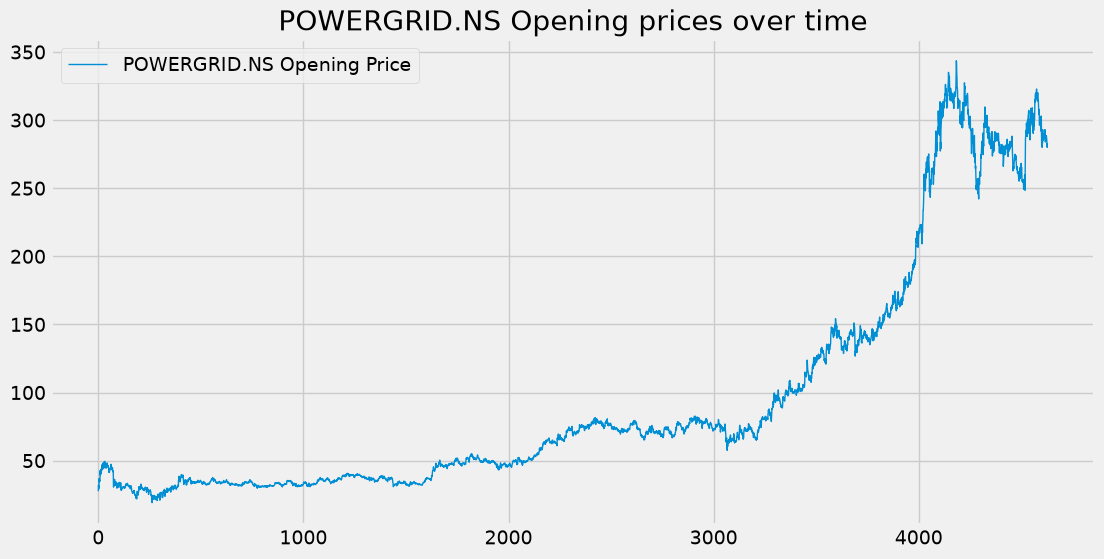

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(df['Open'], label = f'{stock} Opening Price', linewidth = 1)
plt.title(f'{stock} Opening prices over time')
plt.legend()
plt.show()

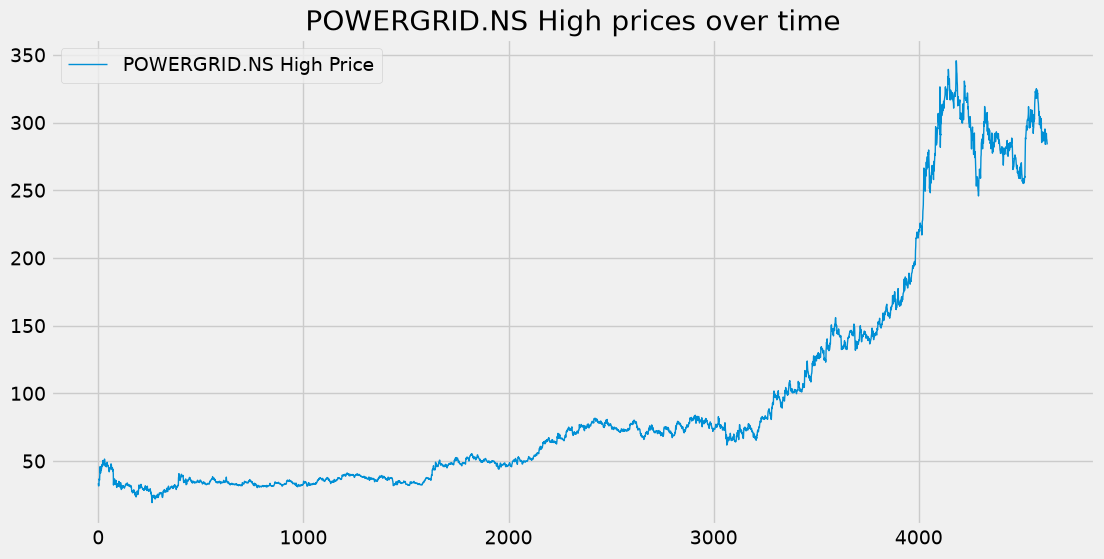

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(df['High'], label = f'{stock} High Price', linewidth = 1)
plt.title(f'{stock} High prices over time')
plt.legend()
plt.show()

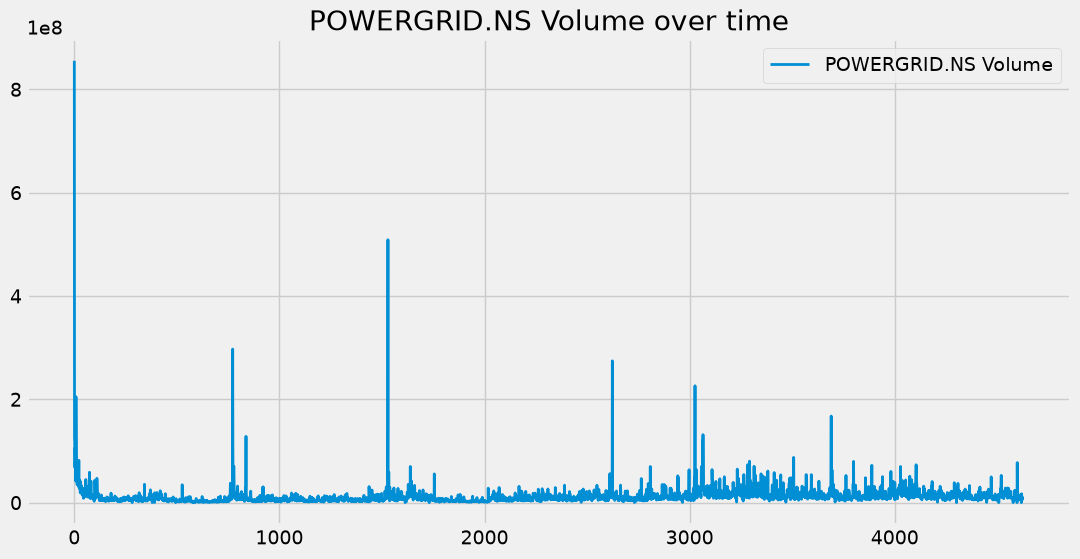

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(df['Volume'], label = f'{stock} Volume', linewidth = 2)
plt.title(f'{stock} Volume over time')
plt.legend()
plt.show()

In [23]:
# Moving Average
# [10, 20, 30, 40, 50, 60, 70, 80, 90]
# moving average for last 5 days -> null null null null 30.0 40.0 50.0

temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90]
print(sum(temp_data[2:7])/5)

50.0


In [24]:
import pandas as pd
df01 = pd.DataFrame(temp_data)

In [25]:
df01.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0


In [26]:
ma100 = df.Close.rolling(100).mean()

In [27]:
ma100

Ticker,POWERGRID.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4623,298.8275
4624,298.7275
4625,298.5800
4626,298.4545


In [28]:
ma200 = df.Close.rolling(200).mean()

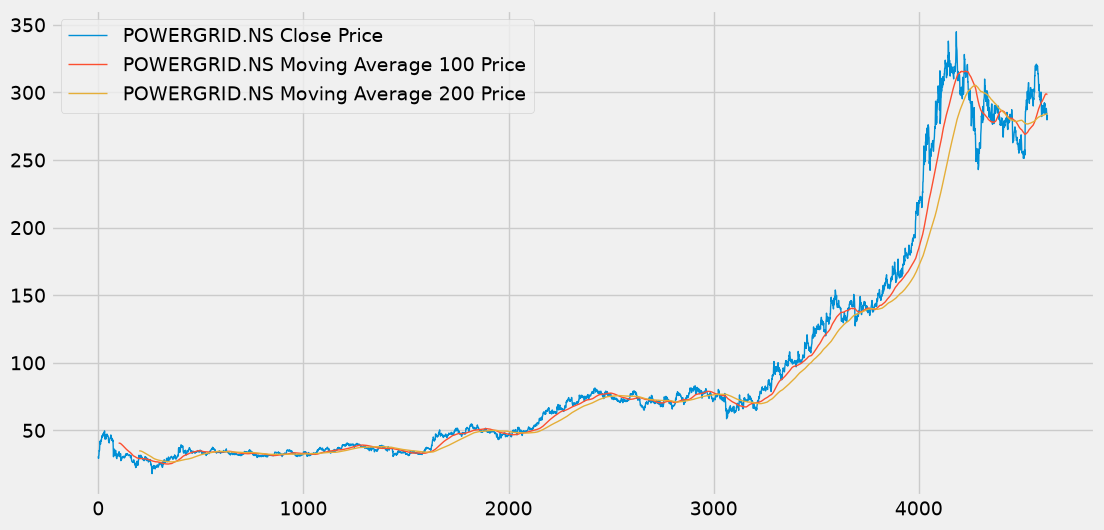

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ma100, label = f'{stock} Moving Average 100 Price', linewidth = 1)
plt.plot(ma200, label = f'{stock} Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [30]:
ema100 = df.Close.ewm(span=100, adjust = False).mean()

In [31]:
ema200 = df['Close'].ewm(span=200, adjust = False).mean()

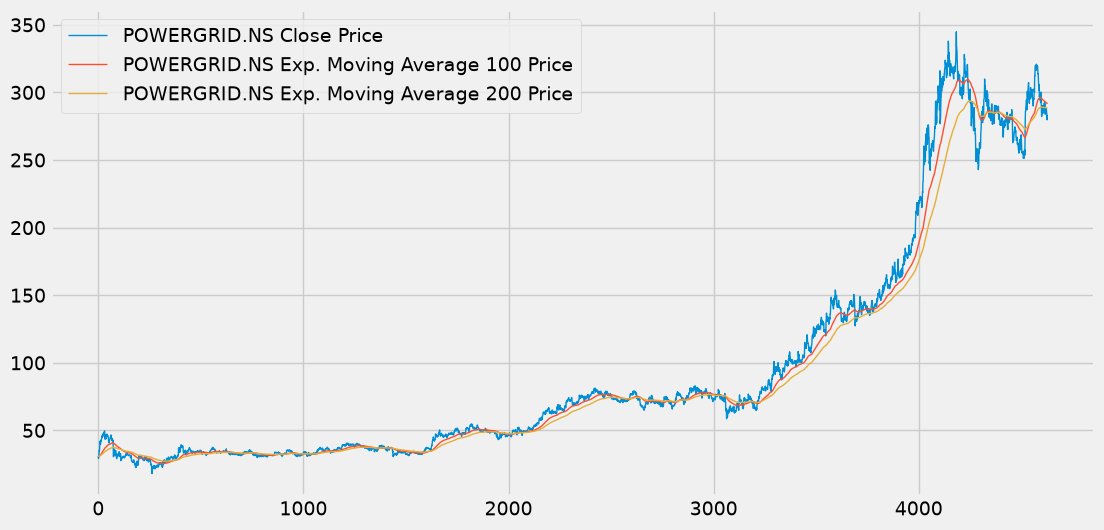

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ema100, label = f'{stock} Exp. Moving Average 100 Price', linewidth = 1)
plt.plot(ema200, label = f'{stock} Exp. Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [33]:
# Training & Testing

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

In [34]:
data_training.shape

(3239, 1)

In [35]:
data_testing.shape

(1389, 1)

In [38]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range = (0, 1))

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/3b/67/be3d369f40d8178ba3bd86635d132e08cb5329b023e4669d9426d84bc007/scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for scipy>=1.10.0 from https://files.pythonhosted.org/packages/95/da/0d1df507cf574b3f224ccc3d45244c9a1d732c81dcb26b1e8a766ae271a8/scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     --------------------------------- ------ 51.2/61.0 kB 1.3 MB/s eta 0:00:01
     ---------------------------------------- 61.0/61.0 kB 1.1 MB/s eta 0:00:00
  Obtaining dependency information for joblib>=1.4.0 from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc443d9ee949/joblib-1.5.3-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.5.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef64


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
data_training_array = scaler.fit_transform(data_training)

In [40]:
data_training_array

array([[0.19808609],
       [0.17371826],
       [0.20447354],
       ...,
       [0.97377319],
       [0.98883461],
       [0.95518705]], shape=(3239, 1))

In [41]:
data_training_array.shape[0]

3239

In [42]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])

x_train, y_train  = np.array(x_train), np.array(y_train)

In [43]:
x_train.shape

(3139, 100, 1)

In [44]:
!pip install tensorflow


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
# Model Building
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

LSTM Input -> 3D Array (batch_size, time_steps, seq_len)
LSTM 2D OR 3D
2D -> (batch_sizem units)
3D -> (batch_size, time_steps, units)

In [46]:
model = Sequential()

model.add(LSTM(units = 50, activation = 'relu', return_sequences = True, input_shape = (x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

c:\Users\91810\OneDrive\Desktop\stock_price_prediction-main\t_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [47]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 26s 207ms/step - loss: 0.0356
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 18s 183ms/step - loss: 0.0097
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 196ms/step - loss: 0.0095
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 23s 235ms/step - loss: 0.0077
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 28s 275ms/step - loss: 0.0073
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 29s 293ms/step - loss: 0.0066
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 31s 304ms/step - loss: 0.0064
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 32s 319ms/step - loss: 0.0062
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 40s 304ms/step - loss: 0.0063
Epoch 10/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 31s 309ms/step - loss: 0.0055
Epoch 11/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 31s 311ms/step - loss: 0.0049
Epoch 12/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 42s 320ms/step - loss: 0.0051
Epoch 13/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 31s 311ms/step - loss: 0.0046
Epoch 14/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 31s 311ms/step - loss: 0.0045
Epoch 15/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 39s 

In [49]:
past_100_days = data_training.tail(100)

In [53]:
final_df = pd.concat([past_100_days, data_testing], ignore_index = True)

In [54]:
final_df.head()

Ticker,POWERGRID.NS
0,70.193451
1,68.770058
2,66.431625
3,66.512955
4,65.963943


In [55]:
input_data = scaler.fit_transform(final_df)

In [56]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

x_test, y_test  = np.array(x_test), np.array(y_test)

In [57]:
x_test.shape

(1389, 100, 1)

In [58]:
y_predicted = model.predict(x_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step


In [59]:
y_predicted.shape

(1389, 1)

In [60]:
scaler.scale_

array([0.00357077])

In [61]:
scaler_factor = 1 / 0.0035166
y_predicted = y_predicted * scaler_factor
y_test = y_test * scaler_factor

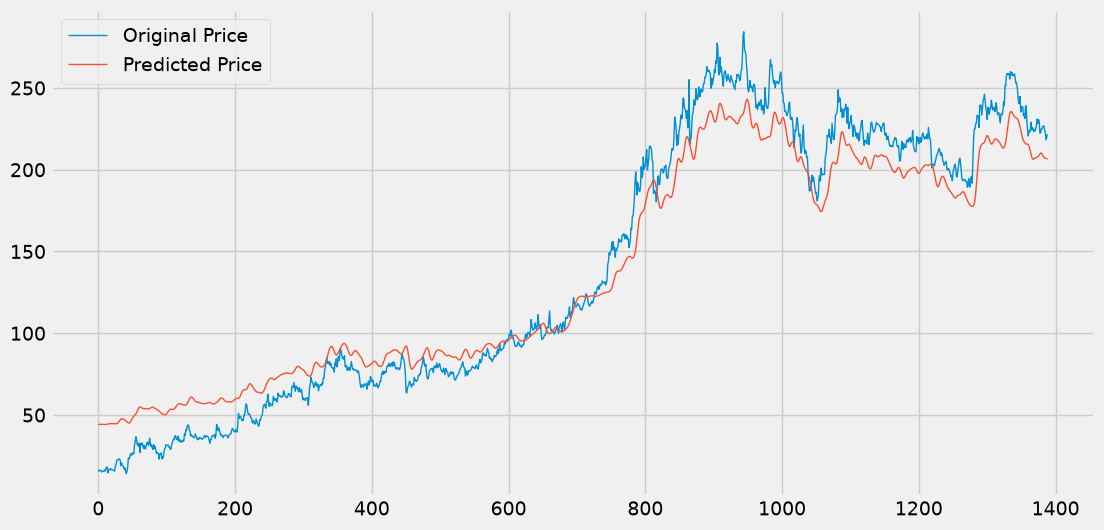

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label = 'Original Price', linewidth = 1)
plt.plot(y_predicted, label = 'Predicted Price', linewidth = 1)
plt.legend()
plt.show()

In [63]:
model.save('stock_dl_model.h5')